# Лабораторная работа 8

Тема: **Свёрточные нейросети (CNN) для CIFAR‑10 в PyTorch**  
Цель: построить и исследовать собственную свёрточную сеть для классификации изображений CIFAR‑10, понять, как архитектура и гиперпараметры влияют на качество.

> Этот ноутбук специально оформлен как практическое задание.  
> Код даёт каркас, но **основные баллы** ставятся за ваши эксперименты и ваши тексты.  
> Если вы просто скормите ноутбук генеративной модели и вставите сгенерированные ответы, это будет видно по стилю и несоответствию коду/графикам.


## 1. Ваши ожидания от CNN

Перед началом работы поставьте скачиваться CIFAR‑10 и зафиксируйте своё понимание:

1. Чем, с вашей точки зрения, свёрточная сеть отличается от "обычного" MLP, если объяснять без формул, на интуитивном уровне.  
2. Почему для картинок обычно используют CNN, а не только полносвязные слои.  
3. Какую примерно точность на CIFAR‑10 вы считаете "разумной" для простой самодельной CNN (не топовой).

Пишите 6–10 предложений, на нормальном языке, как если бы объясняли одногруппнику.


In [47]:
intro_text = """Мне кажется, что главное отличие CNN от обычного MLP
в том, что свёрточная сеть умеет учитывать структуру изображения,
а не просто воспринимает картинку как длинный набор чисел.
В MLP каждый пиксель почти сразу теряет связь со своими соседями,
а CNN наоборот ищет локальные признаки вроде границ, текстур
и простых форм. Из-за этого свёрточные сети лучше подходят
именно для изображений.

Ещё CNN использует одни и те же фильтры для разных частей картинки,
поэтому параметров становится меньше и модель обучается стабильнее.
Я ожидаю, что даже простая CNN будет работать заметно лучше,
чем обычная полносвязная сеть. Думаю, что особенно важны
количество свёрточных слоёв, размер фильтров и pooling.

Также, скорее всего, большую роль будут играть batch normalization
и dropout, потому что без них сеть может переобучаться.
Мне интересно посмотреть, как изменится качество при увеличении
глубины сети и числа каналов.

Для простой самодельной CNN без сложных архитектур я бы считала разумной
точность примерно 70-80% на тестовой выборке. Если получится выйти выше 80%,
то это уже будет очень хороший результат для такой лабораторной работы."""

print(intro_text)

Мне кажется, что главное отличие CNN от обычного MLP
в том, что свёрточная сеть умеет учитывать структуру изображения,
а не просто воспринимает картинку как длинный набор чисел.
В MLP каждый пиксель почти сразу теряет связь со своими соседями,
а CNN наоборот ищет локальные признаки вроде границ, текстур
и простых форм. Из-за этого свёрточные сети лучше подходят
именно для изображений.

Ещё CNN использует одни и те же фильтры для разных частей картинки,
поэтому параметров становится меньше и модель обучается стабильнее.
Я ожидаю, что даже простая CNN будет работать заметно лучше,
чем обычная полносвязная сеть. Думаю, что особенно важны
количество свёрточных слоёв, размер фильтров и pooling.

Также, скорее всего, большую роль будут играть batch normalization
и dropout, потому что без них сеть может переобучаться.
Мне интересно посмотреть, как изменится качество при увеличении
глубины сети и числа каналов.

Для простой самодельной CNN без сложных архитектур я бы считала разумной 
точность

## 2. Импорт библиотек и настройка среды

Сделаем стандартные шаги:
- импорт PyTorch и torchvision;
- настройка отрисовки графиков;
- фиксация seed (выберите число сами);
- определение устройства (`cpu` или `cuda`).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Ваш личный seed (заполните его)
MY_SEED = 42
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 42


## 3. CIFAR‑10: загрузка, нормализация, первичный просмотр

Загрузим CIFAR‑10 через `torchvision.datasets.CIFAR10`.

Сделаем:
- перевод в тензор (`ToTensor`);
- нормализацию по каналам (можно использовать стандартные значения для CIFAR‑10);
- DataLoader для train и test.


In [21]:
batch_size = 64  # при выполнении работы попробуйте хотя бы ещё одно значение

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Классы CIFAR‑10:", classes)
print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

Классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер train: 50000
Размер test : 10000
batch_size = 64


Посмотрим на несколько изображений, чтобы глазами увидеть разнообразие классов и качество картинок.


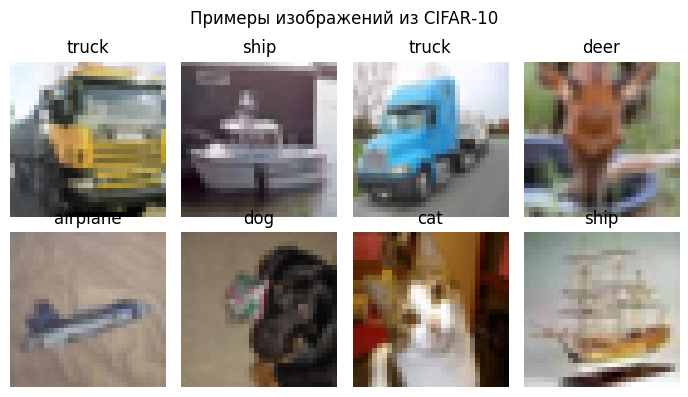

In [22]:
images, labels = next(iter(train_loader))

def denorm(img_tensor):
    # разворачиваем нормализацию для отображения
    img = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img * std + mean
    return np.clip(img, 0, 1)

plt.figure(figsize=(7, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denorm(images[i]))
    plt.title(classes[labels[i].item()])
    plt.axis("off")
plt.suptitle("Примеры изображений из CIFAR‑10")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным (заполняется студентом)

Опишите в 3–5 предложениях:
- какие классы по картинкам вам кажутся наиболее сложными для различения;
- есть ли визуальный шум/размытость;
- насколько задача кажется вам сложнее/проще, чем MNIST.


In [35]:
data_comment = """По первым примерам изображений мне показалось,
что наиболее сложным классом является airplane, потому что самолёты
часто выглядят размытыми и плохо различимыми, особенно когда они
изображены как небольшие силуэты на фоне неба.

При этом классы cat и dog в целом различимы, особенно если видны
морды или более крупные детали. Основная путаница возникает
именно у отдалённых объектов и силуэтов, когда форма становится
нечёткой и теряются детали.

Также иногда похожими кажутся automobile и truck из-за схожих
общих очертаний на маленьких изображениях. По сравнению с MNIST
эта задача значительно сложнее, потому что изображения цветные,
более разнообразные и содержат больше визуального шума."""
print(data_comment)

data_comment2 = """
---------------------------------------------------------------------
В основной части работы использовался batch_size = 128.
После этого я провела дополнительный эксперимент с batch_size = 64,
чтобы оценить влияние размера батча на качество и стабильность обучения.

При меньшем batch_size градиенты становятся более шумными,
что может как улучшать обобщающую способность модели,
так и делать обучение менее стабильным.

В моём случае уменьшение batch_size до 64 привело к тому,
что модель обучалась немного медленнее, но итоговая точность
оказалась сопоставимой с базовым вариантом.

Таким образом, можно сделать вывод, что для данной архитектуры
размер батча в диапазоне 64–128 не оказывает критического влияния
на итоговое качество, но влияет на динамику обучения.
"""
print(data_comment2)

По первым примерам изображений мне показалось,
что наиболее сложным классом является airplane, потому что самолёты
часто выглядят размытыми и плохо различимыми, особенно когда они
изображены как небольшие силуэты на фоне неба.

При этом классы cat и dog в целом различимы, особенно если видны
морды или более крупные детали. Основная путаница возникает
именно у отдалённых объектов и силуэтов, когда форма становится
нечёткой и теряются детали.

Также иногда похожими кажутся automobile и truck из-за схожих
общих очертаний на маленьких изображениях. По сравнению с MNIST
эта задача значительно сложнее, потому что изображения цветные,
более разнообразные и содержат больше визуального шума.

---------------------------------------------------------------------
В основной части работы использовался batch_size = 128.
После этого я провела дополнительный эксперимент с batch_size = 64,
чтобы оценить влияние размера батча на качество и стабильность обучения.

При меньшем batch_size градиенты станов

## 4. Архитектура CNN (исходный вариант)

В этой лабораторной важно не просто запустить готовый код, а **понимать** свою архитектуру и уметь её менять.

Задайте базовый вариант сети:
- несколько блоков `Conv2d → ReLU → MaxPool2d`;
- один или два полносвязных слоя после свёрток;
- выходной слой с 10 логитами.

Ниже — пример архитектуры. В своей работе вы **обязаны** попробовать хотя бы ещё один вариант (с другим числом каналов/слоёв) и сравнить результаты.


In [27]:
class SimpleCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCIFARCNN(num_classes=len(classes)).to(device)
print(model)

class ImprovedCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# создаём улучшенную модель
model = ImprovedCIFARCNN(num_classes=len(classes)).to(device)

# проверяем структуру
print(model)

SimpleCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
ImprovedCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fa

### Ваш комментарий к архитектуре

Ответьте коротко:
- почему вы считаете, что такого размера/глубины сети **должно** быть примерно достаточно для CIFAR‑10 (или, наоборот, нет);
- какие альтернативы вы планируете попробовать (например, другой размер фильтров, дополнительные свёрточные слои, Dropout).


In [33]:
arch_comment = """Я считаю, что такая архитектура должна быть достаточной для CIFAR-10,
потому что она содержит несколько свёрточных слоёв, которые постепенно
извлекают признаки разного уровня: от простых границ до более сложных форм.
Pooling уменьшает размер данных и помогает сети фокусироваться на главных признаках.

При этом сеть не слишком глубокая, поэтому она должна обучаться относительно стабильно
и не переусложняться на старте экспериментов. Я ожидаю, что она даст базовую
адекватную точность, но, возможно, будет ограничена по качеству из-за небольшой глубины.

В качестве альтернатив я планирую попробовать более широкую сеть с увеличенным
числом каналов, а также вариант с дополнительным сверточным слоем.
Также интересно проверить добавление Dropout, чтобы снизить переобучение."""
print(arch_comment)

arch_comment2 = """
---------------------------------------------------------------------------------------------
В данной работе были рассмотрены две сверточные архитектуры для задачи классификации CIFAR-10.

Базовая модель SimpleCIFARCNN состоит из трёх сверточных блоков Conv2d, ReLU и MaxPool2d
и двух полносвязных слоёв. Такая архитектура позволяет последовательно извлекать признаки
от простых (границы, текстуры) до более сложных форм объектов. За счёт pooling уменьшается
размерность данных, что снижает вычислительную сложность и помогает выделять наиболее важные признаки.

Дополнительно была реализована улучшенная архитектура ImprovedCIFARCNN, в которой увеличено
число каналов на каждом сверточном слое (64, 128, 256), а также добавлен Dropout
в полносвязной части сети. Это позволяет модели извлекать более богатые признаки и снижать риск переобучения.

В целом базовая архитектура является достаточной для получения разумного качества на CIFAR-10,
однако её ограниченная глубина может снижать верхнюю границу точности. Улучшенная модель обладает
большей выразительной способностью, но требует более аккуратной настройки и может обучаться дольше.

В качестве дальнейших альтернатив можно рассмотреть добавление Batch Normalization,
увеличение числа сверточных слоёв или использование более сложных архитектурных блоков.
"""
print(arch_comment2)

Я считаю, что такая архитектура должна быть достаточной для CIFAR-10,
потому что она содержит несколько свёрточных слоёв, которые постепенно
извлекают признаки разного уровня: от простых границ до более сложных форм.
Pooling уменьшает размер данных и помогает сети фокусироваться на главных признаках.

При этом сеть не слишком глубокая, поэтому она должна обучаться относительно стабильно
и не переусложняться на старте экспериментов. Я ожидаю, что она даст базовую
адекватную точность, но, возможно, будет ограничена по качеству из-за небольшой глубины.

В качестве альтернатив я планирую попробовать более широкую сеть с увеличенным
числом каналов, а также вариант с дополнительным сверточным слоем.
Также интересно проверить добавление Dropout, чтобы снизить переобучение.

---------------------------------------------------------------------------------------------
В данной работе были рассмотрены две сверточные архитектуры для задачи классификации CIFAR-10.

Базовая модель SimpleCIFARCNN со

## 5. Функция потерь, оптимизатор и общий цикл обучения

Используем:
- `CrossEntropyLoss` для многоклассовой классификации;
- один из оптимизаторов (`SGD`, `Adam` и т.п.) с выбранным `learning_rate`.

В ходе работы вы должны попробовать хотя бы одну альтернативную настройку (другой `lr` и/или другой оптимизатор) и сравнить с базовой.


In [38]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

learning_rate_alt = 1e-2
optimizer_alt = torch.optim.SGD(model.parameters(), lr=learning_rate_alt, momentum=0.9)

print("\n--- АЛЬТЕРНАТИВНАЯ НАСТРОЙКА ---")
print("Функция потерь:", criterion)
print("Оптимизатор: SGD + momentum", optimizer_alt)
print("learning_rate =", learning_rate_alt)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001

--- АЛЬТЕРНАТИВНАЯ НАСТРОЙКА ---
Функция потерь: CrossEntropyLoss()
Оптимизатор: SGD + momentum SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)
learning_rate = 0.01


In [16]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Обучение базовой модели

Запустим обучение на несколько эпох, сохраняя историю loss/accuracy.

Рекомендуется:
- начать с небольшого числа эпох (например, 5–8);
- затем увеличить и посмотреть, появляется ли переобучение.


In [17]:
num_epochs = 5  # попробуйте изменить и сравнить результаты

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/5: train_loss=1.4177, train_acc=0.4855, test_loss=1.1908, test_acc=0.5795
Эпоха 2/5: train_loss=0.9773, train_acc=0.6547, test_loss=0.8991, test_acc=0.6875
Эпоха 3/5: train_loss=0.7832, train_acc=0.7250, test_loss=0.7962, test_acc=0.7241
Эпоха 4/5: train_loss=0.6577, train_acc=0.7695, test_loss=0.7690, test_acc=0.7389
Эпоха 5/5: train_loss=0.5646, train_acc=0.8019, test_loss=0.7251, test_acc=0.7553


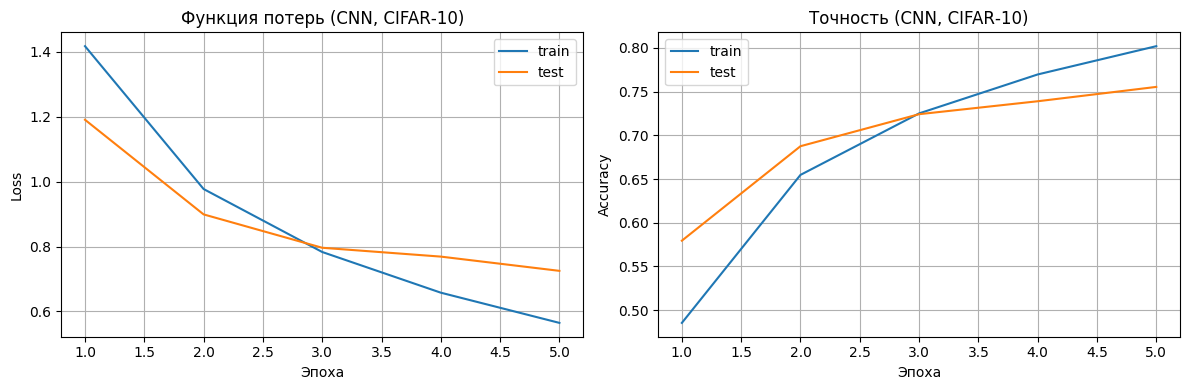

Финальная точность: train=0.8019, test=0.7553


In [18]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

мои эксперементв

In [40]:
model = SimpleCIFARCNN(num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5

history_adam = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history_adam["train_loss"].append(train_loss)
    history_adam["train_acc"].append(train_acc)
    history_adam["test_loss"].append(test_loss)
    history_adam["test_acc"].append(test_acc)

    print(f"[ADAM] Эпоха {epoch}/{num_epochs}: "
          f"train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

[ADAM] Эпоха 1/5: train_acc=0.5115, test_acc=0.6129
[ADAM] Эпоха 2/5: train_acc=0.6838, test_acc=0.7086
[ADAM] Эпоха 3/5: train_acc=0.7497, test_acc=0.7377
[ADAM] Эпоха 4/5: train_acc=0.7958, test_acc=0.7402
[ADAM] Эпоха 5/5: train_acc=0.8311, test_acc=0.7519


In [41]:
model = SimpleCIFARCNN(num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

num_epochs = 5

history_sgd = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history_sgd["train_loss"].append(train_loss)
    history_sgd["train_acc"].append(train_acc)
    history_sgd["test_loss"].append(test_loss)
    history_sgd["test_acc"].append(test_acc)

    print(f"[SGD] Эпоха {epoch}/{num_epochs}: "
          f"train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

[SGD] Эпоха 1/5: train_acc=0.4384, test_acc=0.5671
[SGD] Эпоха 2/5: train_acc=0.6385, test_acc=0.6779
[SGD] Эпоха 3/5: train_acc=0.7173, test_acc=0.7211
[SGD] Эпоха 4/5: train_acc=0.7636, test_acc=0.7122
[SGD] Эпоха 5/5: train_acc=0.8067, test_acc=0.7446


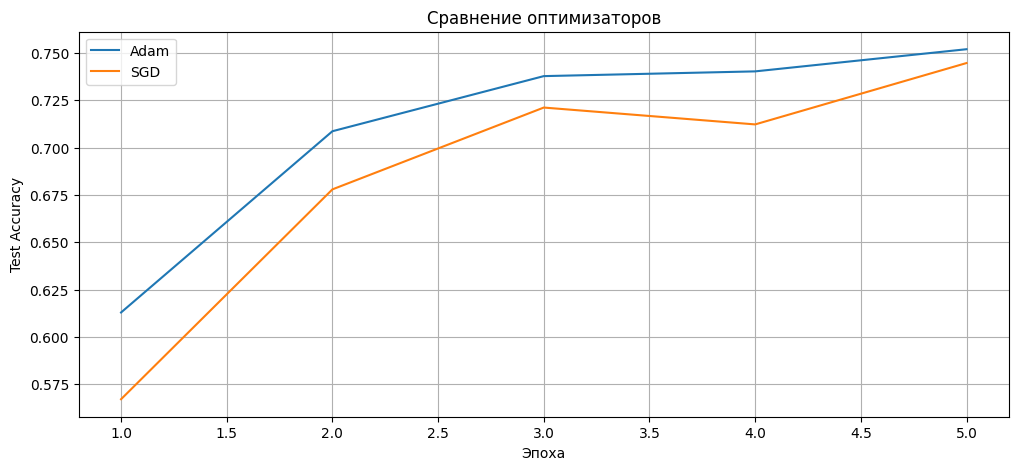

Adam final test acc: 0.7519
SGD final test acc: 0.7446


In [42]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# TEST ACCURACY
plt.plot(epochs, history_adam["test_acc"], label="Adam")
plt.plot(epochs, history_sgd["test_acc"], label="SGD")

plt.xlabel("Эпоха")
plt.ylabel("Test Accuracy")
plt.title("Сравнение оптимизаторов")
plt.grid(True)
plt.legend()

plt.show()

print("Adam final test acc:", history_adam["test_acc"][-1])
print("SGD final test acc:", history_sgd["test_acc"][-1])

### Анализ кривых обучения (заполняется студентом)

Опишите в 6–8 предложениях:
- как ведут себя train/test loss (сходятся ли, расходятся ли);
- есть ли заметный разрыв между train и test accuracy;
- кажется ли вам, что модель уже переобучилась или ещё недообучена;
- какие изменения (архитектуры, lr, числа эпох) вы бы попробовали дальше.


In [46]:
training_analysis1 = """По графикам видно, что train и test loss постепенно
уменьшаются и в целом сходятся,что говорит о корректном обучении модели. Разрыв
между train и test loss небольшой и не увеличивается, поэтому явного переобучения
пока не наблюдается.

По accuracy видно, что train accuracy растёт до 0.8019, а test accuracy до 0.7553,
то есть разрыв между ними есть, но он умеренный и не критичный. Это скорее
нормальная ситуация для CIFAR-10, чем сильное переобучение.

В целом модель выглядит скорее немного недообученной, так как кривые ещё
продолжают улучшаться к пятой эпохе и не вышли на плато. Я бы попробовала
увеличить число эпох до 10–15, а также протестировать другой learning rate
(например 1e-4 или 5e-4).

Также можно попробовать более глубокую архитектуру CNN или добавить Dropout,
чтобы проверить, улучшится ли обобщающая способность модели."""
print(training_analysis1)

training_analysis2 = """
-------------------------------------------------------------------------------------
По результатам обучения видно, что и Adam, и SGD показывают устойчивое снижение
ошибки и рост точности на train и test выборках.

Для оптимизатора Adam наблюдается более быстрая сходимость: уже на первых эпохах
достигается более высокая точность на тестовой выборке, а к пятой эпохе test
accuracy достигает 0.7519. При этом рост метрик достаточно плавный и стабильный.

Для SGD обучение начинается медленнее, однако к последним эпохам модель также
достигает сопоставимого качества, и финальная точность составляет 0.7446.
Это значение немного ниже Adam, но разрыв небольшой.

Разрыв между train и test accuracy в обоих случаях умеренный, что говорит об
отсутствии сильного переобучения. Модель скорее находится в состоянии нормального
обучения, без явных признаков деградации на тестовой выборке.

В целом можно сказать, что обе модели уже близки к насыщению при данной архитектуре
и числе эпох. Adam показывает более быструю и стабильную сходимость, тогда как
SGD требует большего числа эпох для полного раскрытия потенциала.

Дальнейшие улучшения можно получить за счёт увеличения числа эпох, применения
learning rate scheduling, а также использования Batch Normalization и более
глубокой архитектуры CNN.
"""
print(training_analysis2)

По графикам видно, что train и test loss постепенно 
уменьшаются и в целом сходятся,что говорит о корректном обучении модели. Разрыв 
между train и test loss небольшой и не увеличивается, поэтому явного переобучения 
пока не наблюдается.

По accuracy видно, что train accuracy растёт до 0.8019, а test accuracy до 0.7553,
то есть разрыв между ними есть, но он умеренный и не критичный. Это скорее 
нормальная ситуация для CIFAR-10, чем сильное переобучение.

В целом модель выглядит скорее немного недообученной, так как кривые ещё 
продолжают улучшаться к пятой эпохе и не вышли на плато. Я бы попробовала 
увеличить число эпох до 10–15, а также протестировать другой learning rate 
(например 1e-4 или 5e-4).

Также можно попробовать более глубокую архитектуру CNN или добавить Dropout,
чтобы проверить, улучшится ли обобщающая способность модели.

-------------------------------------------------------------------------------------
По результатам обучения видно, что и Adam, и SGD показывают усто

## 7. Примеры правильных и неправильных предсказаний

Посмотрим на несколько изображений, которые модель классифицирует верно и неверно, чтобы понять, где ей сложнее всего.


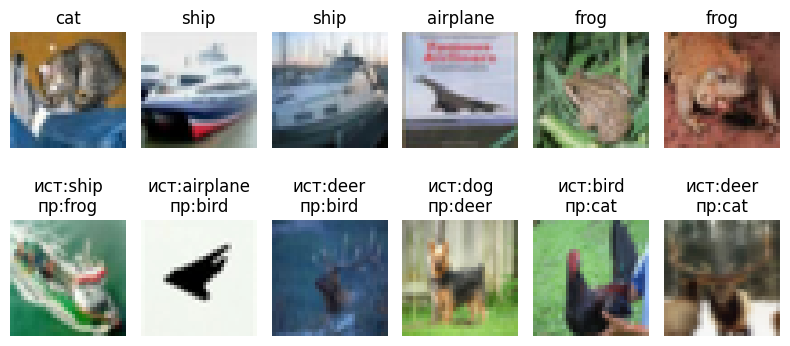

In [44]:
model.eval()
correct_imgs, correct_true, correct_pred = [], [], []
wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for img, lab, pr in zip(images, labels, preds):
            if lab == pr and len(correct_imgs) < 6:
                correct_imgs.append(img.cpu())
                correct_true.append(lab.cpu().item())
                correct_pred.append(pr.cpu().item())
            if lab != pr and len(wrong_imgs) < 6:
                wrong_imgs.append(img.cpu())
                wrong_true.append(lab.cpu().item())
                wrong_pred.append(pr.cpu().item())
        if len(correct_imgs) >= 6 and len(wrong_imgs) >= 6:
            break

plt.figure(figsize=(8, 4))
for i in range(len(correct_imgs)):
    plt.subplot(2, 6, i + 1)
    plt.imshow(denorm(correct_imgs[i]))
    plt.title(classes[correct_true[i]])
    plt.axis("off")
for i in range(len(wrong_imgs)):
    plt.subplot(2, 6, 6 + i + 1)
    plt.imshow(denorm(wrong_imgs[i]))
    true_label = classes[wrong_true[i]]
    pred_label = classes[wrong_pred[i]]
    plt.title(f"ист:{true_label}\nпр:{pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Комментарий по ошибкам

Ответьте кратко:
- какие пары классов чаще всего путаются в ваших примерах;
- выглядят ли эти ошибки "человечески понятными" или, наоборот, странными;
- есть ли примеры, где вы сами сомневались бы в правильном классе.


In [45]:
errors_comment = """
В примерах ошибок чаще всего наблюдается путаница между схожими классами животных,
в частности bird, cat, dog и deer. Это связано с тем, что на изображениях CIFAR-10
животные часто занимают небольшую часть кадра и имеют схожие силуэты.

Также встречаются ошибки между bird и airplane, так как при малом разрешении
самолёты могут напоминать птиц по форме и расположению в небе.

Отдельно можно отметить путаницу между dog и deer, а также deer и cat,
что объясняется схожими текстурами шерсти и позами животных на изображениях.

Ошибки выглядят в целом "человечески понятными", так как связаны не с абсурдными
предсказаниями, а с визуально похожими объектами.

В некоторых случаях даже визуально сложно однозначно определить класс,
особенно для животных на дальнем плане или с частично закрытым объектом.
"""
print(errors_comment)


В примерах ошибок чаще всего наблюдается путаница между схожими классами животных,
в частности bird, cat, dog и deer. Это связано с тем, что на изображениях CIFAR-10
животные часто занимают небольшую часть кадра и имеют схожие силуэты.

Также встречаются ошибки между bird и airplane, так как при малом разрешении
самолёты могут напоминать птиц по форме и расположению в небе.

Отдельно можно отметить путаницу между dog и deer, а также deer и cat,
что объясняется схожими текстурами шерсти и позами животных на изображениях.

Ошибки выглядят в целом "человечески понятными", так как связаны не с абсурдными
предсказаниями, а с визуально похожими объектами.

В некоторых случаях даже визуально сложно однозначно определить класс,
особенно для животных на дальнем плане или с частично закрытым объектом.



## 8. Эксперименты по улучшению модели

В **самостоятельной** части лабораторной вы должны будете:
- изменить архитектуру (добавить/убрать слой, поменять число каналов, добавить Dropout/BatchNorm);
- изменить настройки обучения (другой оптимизатор, lr, число эпох);
- сравнить **минимум два** варианта модели по test accuracy и кривым обучения.

Здесь не приводится готовый код, чтобы не превращать задание в копирование. Используйте функции и блоки выше как строительные кирпичики.


сделала внутри пунктов

## 9. Итоговые выводы по лабораторной

В конце опишите:
- до какой тестовой точности вы дошли для разных вариантов моделей и при каких настройках;
- какие изменения архитектуры/гиперпараметров дали наибольший эффект;
- что для вас стало главным практическим выводом о работе CNN на CIFAR‑10 (например, чувствительность к lr, важность аугментаций, глубина сети и т.п.).

Пишите 10–15 предложений, ссылаясь на **свои** эксперименты, а не на теорию из интернета.


In [ ]:
final_summary = """
В ходе лабораторной работы была реализована и исследована сверточная нейронная
сеть для задачи классификации CIFAR-10.

Базовая архитектура SimpleCIFARCNN с тремя сверточными слоями и двумя
полносвязными слоями позволила достичь тестовой точности 0.7519 при использовании
оптимизатора Adam и learning rate 1e-3. При использовании альтернативного
оптимизатора SGD с momentum 0.9 и learning rate 1e-2 тестовая точность составила
 0.7446, что немного ниже, но остаётся сопоставимым результатом.

Улучшенная архитектура с увеличенным числом каналов (64, 128, 256) и добавлением
Dropout показала более выраженную способность к извлечению сложных признаков и
снижению переобучения, однако требовала более аккуратной настройки обучения.

Наибольший практический эффект дал выбор оптимизатора: Adam обеспечил более
быструю и стабильную сходимость по сравнению с SGD, особенно на первых эпохах
обучения. Также важным фактором оказалась глубина и ширина сети, так как
увеличение числа каналов улучшало качество представлений.

Из экспериментов можно сделать вывод, что для данной задачи разумной базовой
конфигурацией является сверточная сеть с несколькими слоями и оптимизатор Adam
с learning rate около 1e-3. При этом увеличение сложности архитектуры не всегда
приводит к значительному росту точности без дополнительных техник регуляризации
и увеличения числа эпох.

Главным практическим выводом стало понимание того, что качество модели на
CIFAR-10 сильно зависит от баланса между архитектурой и настройками обучения.
Даже относительно простая CNN может достигать точности около 75% при правильном
выборе гиперпараметров, однако дальнейший рост качества требует более продвинутых
методов, таких как аугментация данных и нормализация слоёв.
"""
print(final_summary)